In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
class myNN(nn.Module):
    
    def __init__(self):
        super().__init__()

        self.w1 = torch.tensor(1.43)
        self.b1 = torch.tensor(-0.61)
    
        self.w2 = torch.tensor(2.63)
        self.b2 = torch.tensor(-0.27)
    
        self.w3 = torch.tensor(-3.89)
        self.w4 = torch.tensor(1.35)
    
    def forward(self, input_values):
        
        top_x_axis_values = (input_values * self.w1) + self.b1
        bottom_x_axis_values = (input_values * self.w2) + self.b2
        
        top_y_axis_values = F.relu(top_x_axis_values)
        bottom_y_axis_values = F.relu(bottom_x_axis_values)
        
        output_values = (top_y_axis_values * self.w3) + (bottom_y_axis_values * self.w4)
        
        return output_values
    

In [11]:
model = myNN()

doses = torch.tensor([0.0, 0.5, 1.0])
model(doses)


tensor([ 0.0000,  1.0023, -0.0038])

In [12]:
torch.round(model(doses), decimals=2)

tensor([0., 1., -0.])

In [22]:
input_doses = torch.linspace(start=0, end=1, steps=11)

input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [23]:
top_x_axis_values = (model.w1 * input_doses) + model.b1
top_x_axis_values

tensor([-0.6100, -0.4670, -0.3240, -0.1810, -0.0380,  0.1050,  0.2480,  0.3910,
         0.5340,  0.6770,  0.8200])

In [24]:
top_y_axis_values = F.relu(top_x_axis_values)
top_y_axis_values

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1050, 0.2480, 0.3910, 0.5340,
        0.6770, 0.8200])

Text(0.5, 0, 'Dose')

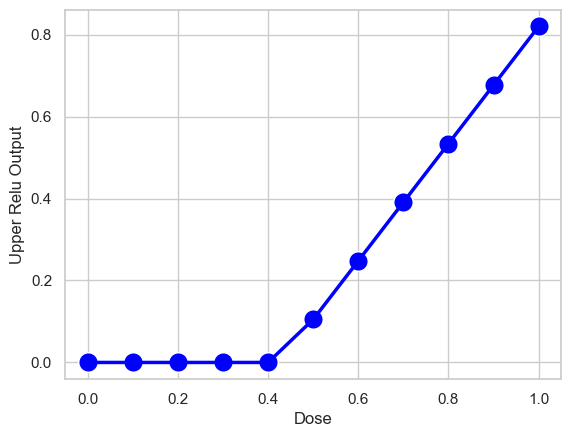

In [25]:
sns.set(style='whitegrid')
sns.scatterplot(x=input_doses,
                y=top_y_axis_values,
                color='blue',
                s=200)
sns.lineplot(x=input_doses,
             y=top_y_axis_values,
             color='blue',
             linewidth=2.5)

plt.ylabel('Upper Relu Output')
plt.xlabel('Dose')


In [26]:
bottom_x_axis_values = (model.w2 * input_doses) + model.b2
bottom_x_axis_values

tensor([-0.2700, -0.0070,  0.2560,  0.5190,  0.7820,  1.0450,  1.3080,  1.5710,
         1.8340,  2.0970,  2.3600])

In [34]:
bottom_y_axis_values = F.relu(bottom_x_axis_values)
bottom_y_axis_values

tensor([0.0000, 0.0000, 0.2560, 0.5190, 0.7820, 1.0450, 1.3080, 1.5710, 1.8340,
        2.0970, 2.3600])

Text(0.5, 0, 'Dose')

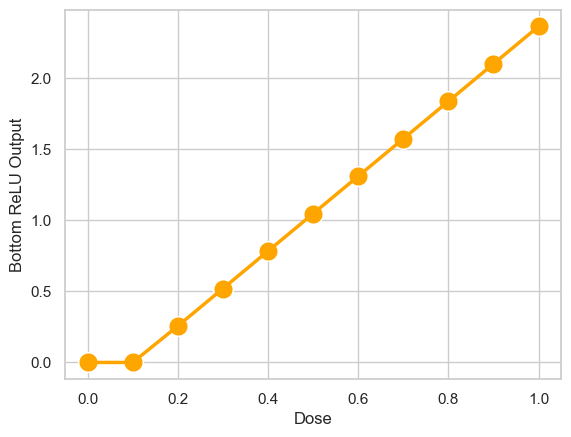

In [35]:
sns.set(style='whitegrid')
sns.scatterplot(x=input_doses,
                y=bottom_y_axis_values,
                color='orange',
                s=200)
sns.lineplot(x=input_doses,
             y=bottom_y_axis_values,
             color='orange',
             linewidth=2.5)

plt.ylabel('Bottom ReLU Output')
plt.xlabel('Dose')

Text(0.5, 0, 'Dose')

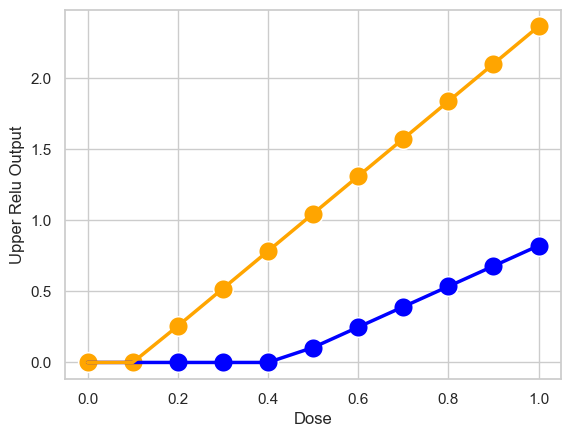

In [ ]:
sns.set(style='whitegrid')

sns.scatterplot(x=input_doses,
                y=top_y_axis_values,
                color='blue',
                s=200)
sns.lineplot(x=input_doses,
             y=top_y_axis_values,
             color='blue',
             linewidth=2.5)

sns.scatterplot(x=input_doses,
                y=bottom_y_axis_values,
                color='orange',
                s=200)
sns.lineplot(x=input_doses,
             y=bottom_y_axis_values,
             color='orange',
             linewidth=2.5)

plt.ylabel('Upper Relu Output')
plt.xlabel('Dose')



In [37]:
final_top_y_axis_values = top_y_axis_values * model.w3
final_top_y_axis_values

tensor([-0.0000, -0.0000, -0.0000, -0.0000, -0.0000, -0.4084, -0.9647, -1.5210,
        -2.0773, -2.6335, -3.1898])

In [38]:
final_bottom_y_axis_values = bottom_y_axis_values * model.w4
final_bottom_y_axis_values

tensor([0.0000, 0.0000, 0.3456, 0.7007, 1.0557, 1.4108, 1.7658, 2.1209, 2.4759,
        2.8310, 3.1860])

Text(0.5, 0, 'Dose')

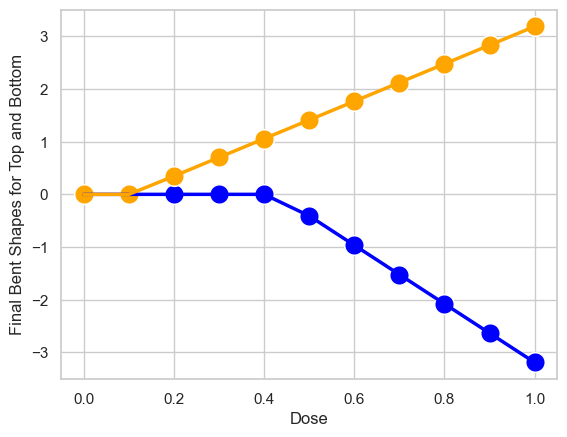

In [39]:
sns.set(style='whitegrid')
sns.scatterplot(x=input_doses,
                y=final_top_y_axis_values,
                color='blue',
                s=200)
sns.lineplot(x=input_doses,
             y=final_top_y_axis_values,
             color='blue',
             linewidth=2.5)
sns.scatterplot(x=input_doses,
                y=final_bottom_y_axis_values,
                color='orange',
                s=200)
sns.lineplot(x=input_doses,
             y=final_bottom_y_axis_values,
             color='orange',
             linewidth=2.5)
plt.ylabel('Final Bent Shapes for Top and Bottom')
plt.xlabel('Dose')

In [41]:
final_bent_shape = final_top_y_axis_values + final_bottom_y_axis_values
final_bent_shape

tensor([ 0.0000,  0.0000,  0.3456,  0.7007,  1.0557,  1.0023,  0.8011,  0.5999,
         0.3986,  0.1974, -0.0038])

Text(0.5, 0, 'Doses')

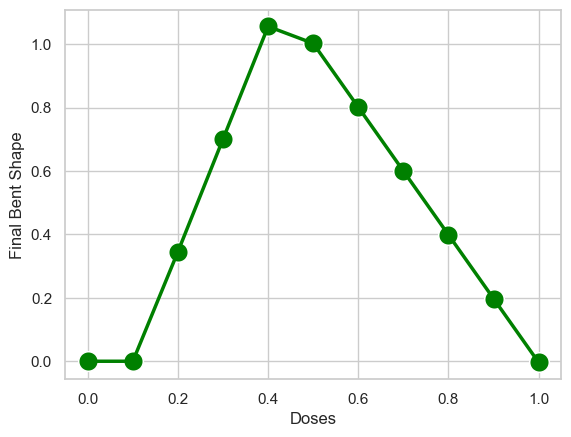

In [ ]:
sns.set(style='whitegrid')
sns.scatterplot(x=input_doses,
                y=final_bent_shape,
                color='green',
                s=200)
sns.lineplot(x=input_doses,
             y=final_bent_shape,
             color='green',
             linewidth=2.5)
plt.ylabel('Final Bent Shape')
plt.xlabel('Dose')